In [1]:
"""
TensorFlow Tutorial for Neural Architecture Codesign (NAC)
This tutorial demonstrates how to use the main codebase for:
1. Global search on MNIST dataset with custom architectures
2. Training and evaluating models
3. Estimating hardware metrics
4. Visualizing the results of the search
"""

import os
import sys

import argparse
import yaml
import optuna
import tensorflow as tf
import pandas as pd
import time
from rule4ml.models.estimators import MultiModelEstimator
print("hello1")

# Import utilities from main codebase
from utils.tf_data_preprocessing import load_and_preprocess_mnist
from utils.tf_model_builder import (
    build_mlp_from_config,
    build_deepsets_model,
    load_yaml_config
)
print("hello2")

from utils.tf_processor import train_model, evaluate_model, get_model_metrics
from utils.tf_bops import get_MLP_bops_tf
from models.tf_blocks import DeepSetsArchitecture_tf
print("hello3")
from utils.tf_visualization import *
print("hello4")


import os
import sys
import yaml
import optuna
import tensorflow as tf
import pandas as pd
import numpy as np
import time
import re
import itertools
import math
import ast
import matplotlib.pyplot as plt
import plotly.graph_objects as go
# To display plots directly in the notebook
%matplotlib inline

/home/users/ddemler/miniconda3/envs/FastMLTutorial/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-08-14 07:11:24.555728: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-14 07:11:24.559239: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-14 07:11:24.570372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755180684.588841 2231576 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755180684.594388 2231

hello1
hello2
hello3
hello4


In [2]:


class GlobalSearchTF:
    """Main class for conducting global search with TensorFlow models."""
    
    def __init__(self, search_space_path=None, hls_config=None, results_dir="./results_tf"):
        """
        Initialize global search.
        
        Parameters:
            search_space_path: Path to YAML file with search space
            hls_config: Hardware configuration for rule4ml
            results_dir: Directory to save results
        """
        self.results_dir = results_dir
        os.makedirs(results_dir, exist_ok=True)
        
        if search_space_path and os.path.exists(search_space_path):
             with open(search_space_path, 'r') as f:
                self.search_space = yaml.safe_load(f)
        else:
            self.search_space = self.get_default_search_space()
        
        self.hls_config = hls_config or self.get_default_hls_config()
        self.results = []
    
    def get_default_search_space(self):
        """Returns default search space for MLP on MNIST."""
        return {
            "num_layers": [2, 3],
            "hidden_units1": [8, 16, 32, 64, 128],
            "activation1": ["relu", "tanh", "sigmoid"],
            "batchnorm1": [True, False],
            "hidden_units2": [8, 16, 32, 64],
            "activation2": ["relu", "tanh", "sigmoid"],
            "batchnorm2": [True, False],
        }
    
    def get_default_hls_config(self):
        """Returns default HLS configuration."""
        return {
            "model": {"precision": "ap_fixed<8,3>", "reuse_factor": 1, "strategy": "Latency"},
            "board": "zcu102"
        }
    
    def create_mlp_objective(self, x_train, y_train, x_val, y_val, epochs=10):
        """Creates objective function for MLP optimization."""
        def objective(trial):
            num_layers = trial.suggest_categorical("num_layers", self.search_space["num_layers"])
            config = {
                "num_layers": num_layers,
                "hidden_units1": trial.suggest_categorical("hidden_units1", self.search_space["hidden_units1"]),
                "activation1": trial.suggest_categorical("activation1", self.search_space["activation1"]),
                "batchnorm1": trial.suggest_categorical("batchnorm1", self.search_space["batchnorm1"]),
            }
            if num_layers >= 3:
                config["hidden_units2"] = trial.suggest_categorical("hidden_units2", self.search_space["hidden_units2"])
                config["activation2"] = trial.suggest_categorical("activation2", self.search_space["activation2"])
                config["batchnorm2"] = trial.suggest_categorical("batchnorm2", self.search_space["batchnorm2"])
            
            input_size = x_train.shape[1]
            num_classes = y_train.shape[1]
            model = build_mlp_from_config(config, input_size=input_size, num_classes=num_classes)
            
            train_model(model, (x_train, y_train), (x_val, y_val), epochs=epochs, batch_size=128, patience=3, verbose=0)
            val_metrics = evaluate_model(model, (x_val, y_val))
            val_accuracy = val_metrics['accuracy']
            
            bops = self.calculate_mlp_bops(config, input_size, num_classes)
            
            # Simplified hardware metrics (as rule4ml might not be installed)
            avg_resource = np.random.rand() * 10 # Dummy value
            clock_cycles = np.random.randint(1000, 5000) # Dummy value
            
            print(f"Trial {trial.number}: Accuracy={val_accuracy:.4f}, BOPs={bops}, "
                  f"Avg Resource={avg_resource:.2f}, Clock Cycles={clock_cycles}")
            
            self.results.append({
                'trial': trial.number,
                'accuracy': val_accuracy,
                'bops': bops,
                'avg_resource': avg_resource,
                'clock_cycles': clock_cycles,
                'params': trial.params
            })
            
            return val_accuracy, bops, avg_resource, clock_cycles
        
        return objective

    def calculate_mlp_bops(self, config, input_size, num_classes, bit_width=32):
        """Calculate BOPs for MLP architecture."""
        bops = 0
        bops += input_size * config["hidden_units1"] * bit_width**2
        if config["num_layers"] >= 3:
            bops += config["hidden_units1"] * config["hidden_units2"] * bit_width**2
            bops += config["hidden_units2"] * num_classes * bit_width**2
        else:
            bops += config["hidden_units1"] * num_classes * bit_width**2
        return bops

    def run_search(self, model_type='mlp', n_trials=10, epochs=10, dataset='mnist',
                  subset_size=10000, resize_val=8, objectives=None, maximize_flags=None):
        """Run global search."""
        print(f"\n{'='*50}\nStarting {model_type.upper()} Global Search on {dataset.upper()}\n{'='*50}\n")
        self.objective_names = objectives or ['accuracy', 'bops', 'avg_resource', 'clock_cycles']
        self.maximize_flags = maximize_flags or [True, False, False, False]

        x_train, y_train, x_val, y_val = load_and_preprocess_mnist(
            resize_val=resize_val, subset_size=subset_size, flatten=(model_type == 'mlp'), one_hot=True
        )

        objective = self.create_mlp_objective(x_train, y_train, x_val, y_val, epochs)
        directions = ["maximize" if flag else "minimize" for flag in self.maximize_flags]

        study = optuna.create_study(directions=directions, sampler=optuna.samplers.NSGAIISampler())
        study.optimize(objective, n_trials=n_trials)

        self.save_results(model_type)
        return study
    
    def save_results(self, model_type):
        """Save search results to a CSV file."""
        df = pd.DataFrame(self.results)
        csv_file = os.path.join(self.results_dir, f"{model_type}_search_results.csv")
        df.to_csv(csv_file, index=False)
        print(f"\nCSV results saved to {csv_file}")

In [3]:
# --- Configuration ---
MODEL_TYPE = "mlp"
N_TRIALS = 20  # Number of optimization trials
EPOCHS = 5      # Training epochs for each trial
SUBSET_SIZE = 5000 # Use a smaller subset for faster runs
RESIZE_VAL = 8     # Resize images to 8x8
RESULTS_DIR = "./results_tf_notebook"

# --- Objectives Configuration ---
# Names of the objectives you are optimizing
OBJECTIVE_NAMES = ['accuracy', 'bops', 'avg_resource', 'clock_cycles']
# For each objective, specify if you want to maximize (True) or minimize (False)
MAXIMIZE_FLAGS = [True, False, False, False]
OBJECTIVE_INFO = list(zip(OBJECTIVE_NAMES, MAXIMIZE_FLAGS))


# Initialize and run the global search
search_space_path = 'examples/mnist_search_spaces.yaml'
searcher = GlobalSearchTF(results_dir=RESULTS_DIR, search_space_path=search_space_path)

study = searcher.run_search(
    model_type=MODEL_TYPE,
    n_trials=N_TRIALS,
    epochs=EPOCHS,
    subset_size=SUBSET_SIZE,
    resize_val=RESIZE_VAL,
    objectives=OBJECTIVE_NAMES,
    maximize_flags=MAXIMIZE_FLAGS
)


Starting MLP Global Search on MNIST



2025-08-14 07:11:29.138878: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
[I 2025-08-14 07:11:29,223] A new study created in memory with name: no-name-c436f8b4-69ca-46a7-ac71-2b8e5fdd24c4


Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (5000, 64), x_val shape: (5000, 64)
  y_train shape: (5000, 10), y_val shape: (5000, 10)


[I 2025-08-14 07:11:31,439] Trial 0 finished with values: [0.7821999788284302, 12910592.0, 1.024892805393125, 4578.0] and parameters: {'num_layers': 3, 'hidden_units1': 128, 'activation1': 'tanh', 'batchnorm1': True, 'hidden_units2': 32, 'activation2': 'relu', 'batchnorm2': False}.


Trial 0: Accuracy=0.7822, BOPs=12910592, Avg Resource=1.02, Clock Cycles=4578


...

Trial 17: Accuracy=0.7164, BOPs=2424832, Avg Resource=7.75, Clock Cycles=3722


[I 2025-08-14 07:12:04,822] Trial 18 finished with values: [0.41519999504089355, 819200.0, 3.8981354219609896, 3166.0] and parameters: {'num_layers': 3, 'hidden_units1': 8, 'activation1': 'relu', 'batchnorm1': False, 'hidden_units2': 16, 'activation2': 'relu', 'batchnorm2': False}.


Trial 18: Accuracy=0.4152, BOPs=819200, Avg Resource=3.90, Clock Cycles=3166


[I 2025-08-14 07:12:06,414] Trial 19 finished with values: [0.7192000150680542, 4849664.0, 3.2001529245707685, 4673.0] and parameters: {'num_layers': 2, 'hidden_units1': 64, 'activation1': 'tanh', 'batchnorm1': False}.


Trial 19: Accuracy=0.7192, BOPs=4849664, Avg Resource=3.20, Clock Cycles=4673

CSV results saved to ./results_tf_notebook/mlp_search_results.csv


In [4]:
# --- Display Results ---
print("\n" + "="*50)
print("BEST TRIALS FOUND BY OPTUNA")
print("="*50)

# The 'best_trials' attribute of a study contains the Pareto optimal solutions
for i, trial in enumerate(study.best_trials):
    print(f"\nRank {i+1} (Trial {trial.number}):")
    # Create a clean dictionary of objective values for printing
    values_dict = {name: val for name, val in zip(OBJECTIVE_NAMES, trial.values)}
    print(f"  Values: {values_dict}")
    print(f"  Params: {trial.params}")


BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 0):
  Values: {'accuracy': 0.7821999788284302, 'bops': 12910592.0, 'avg_resource': 1.024892805393125, 'clock_cycles': 4578.0}
  Params: {'num_layers': 3, 'hidden_units1': 128, 'activation1': 'tanh', 'batchnorm1': True, 'hidden_units2': 32, 'activation2': 'relu', 'batchnorm2': False}

Rank 2 (Trial 1):
  Values: {'accuracy': 0.626800000667572, 'bops': 6619136.0, 'avg_resource': 0.7110837945047466, 'clock_cycles': 4286.0}
  Params: {'num_layers': 3, 'hidden_units1': 64, 'activation1': 'sigmoid', 'batchnorm1': False, 'hidden_units2': 32, 'activation2': 'tanh', 'batchnorm2': True}

Rank 3 (Trial 2):
  Values: {'accuracy': 0.5460000038146973, 'bops': 1212416.0, 'avg_resource': 1.0385039586031497, 'clock_cycles': 1742.0}
  Params: {'num_layers': 2, 'hidden_units1': 16, 'activation1': 'sigmoid', 'batchnorm1': True}

Rank 4 (Trial 3):
  Values: {'accuracy': 0.5192000269889832, 'bops': 819200.0, 'avg_resource': 6.556542465090187, 'clock_cycles': 1851.


PLOTTING RESULTS

--- 2D Pareto Fronts ---
2D Pareto fronts plot saved to ./results_tf_notebook/pareto_fronts_2d.png


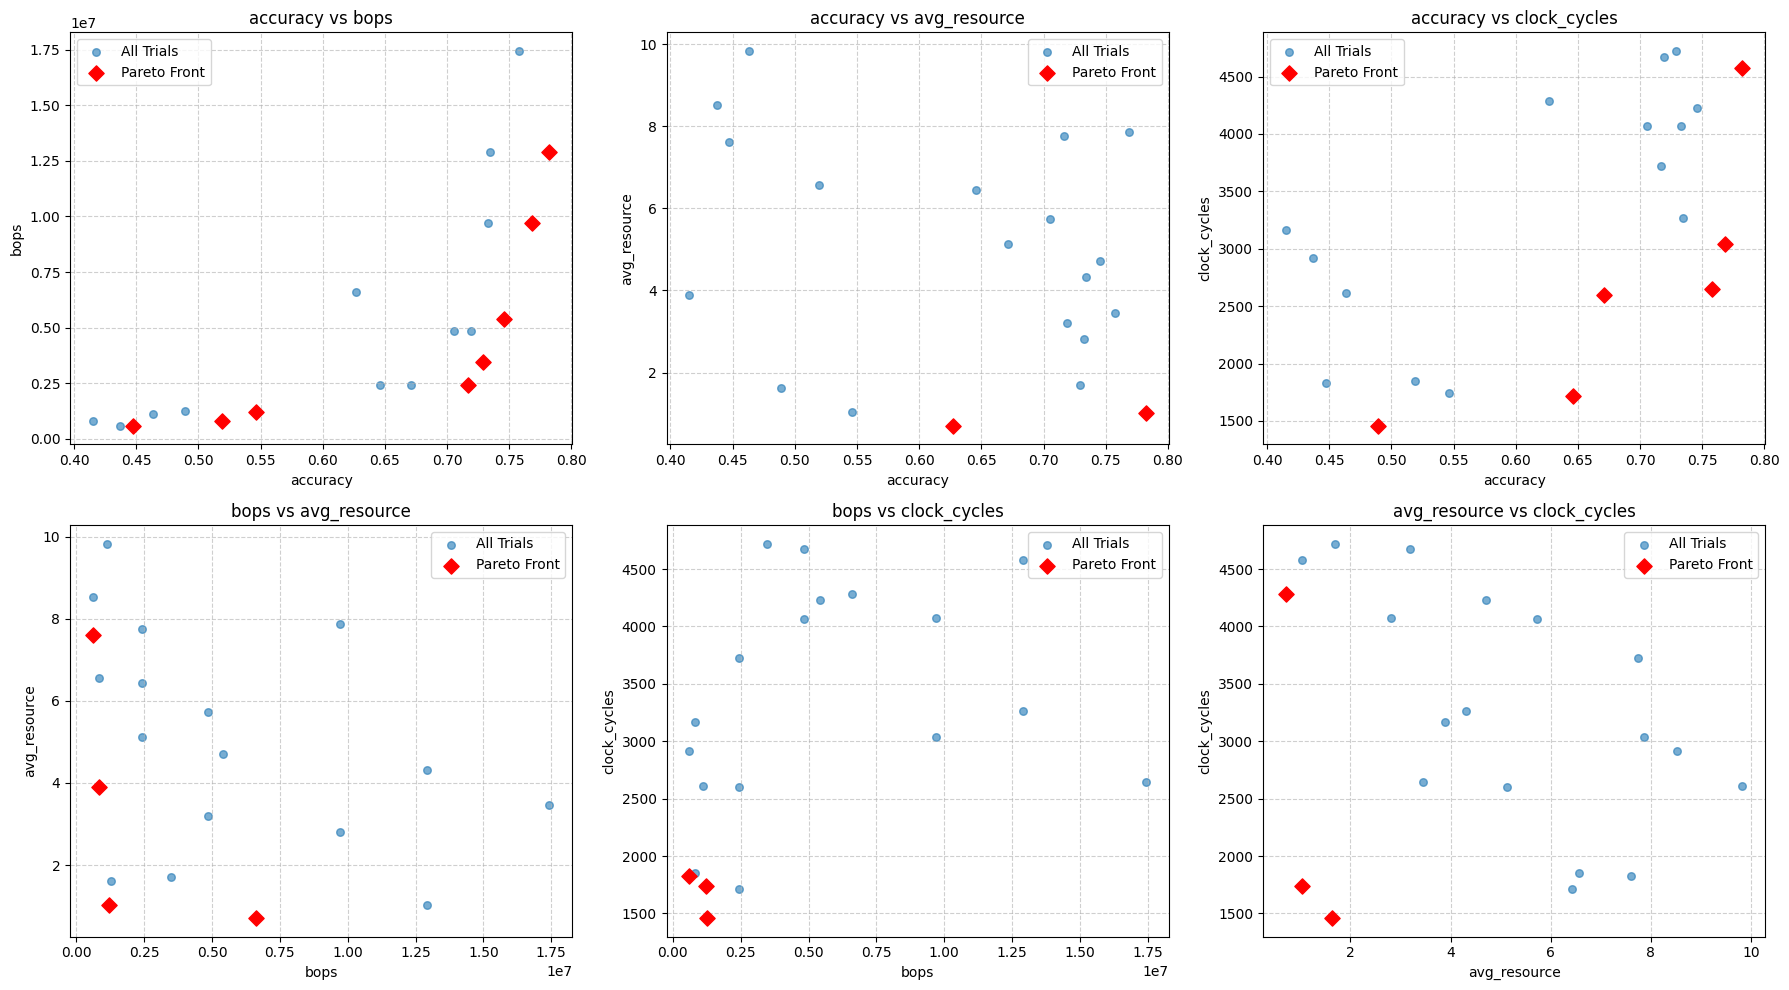


--- 3D Pareto Front Heatmap ---
3D Pareto front plot saved to ./results_tf_notebook/pareto_front_3d.html


In [5]:
# --- Plotting Results ---
print("\n" + "="*50)
print("PLOTTING RESULTS")
print("="*50)

# Load the results from the CSV file into a pandas DataFrame
results_df = pd.DataFrame(searcher.results)

if not results_df.empty:
    # Sanitize column names for consistency
    results_df.columns = [col.lower().replace(" ", "_") for col in results_df.columns]
    
    # Generate and display the 2D Pareto front plots
    print("\n--- 2D Pareto Fronts ---")
    plot_pareto_fronts(results_df, OBJECTIVE_INFO, save_dir=searcher.results_dir)

    # Generate and display the 3D Pareto front plot if enough objectives exist
    if len(OBJECTIVE_NAMES) >= 4:
        print("\n--- 3D Pareto Front Heatmap ---")
        # Plot using the first 4 objectives
        plot_3d_pareto_front_heatmap(results_df, OBJECTIVE_INFO[:4], save_dir=searcher.results_dir)
    else:
        print("\nSkipping 3D plot: At least 4 objectives are required.")
else:
    print("No results to plot.")